In [ ]:
!pip install transformers==4.57.6 optimum==1.26.0 accelerate==1.8.0

In [ ]:
!pip install peft==0.17.0
!pip install json-repair

In [ ]:
!huggingface-cli login --token "hf_123"

In [ ]:
# # ====> Download the finetuned LoRA

# from huggingface_hub import snapshot_download

# # Download only the specific checkpoint directory
# snapshot_download(
#     repo_id="bakrianoo/arabic-legal-documents-ocr-1.0",
#     allow_patterns="checkpoints/checkpoint-1640/*",
#     local_dir="./downloaded_checkpoint",
#     local_dir_use_symlinks=False
# )

## Evaluate

In [ ]:
from transformers import AutoProcessor, Gemma3ForConditionalGeneration
from IPython.display import Image as IPImage, display

from PIL import Image
import torch
import json_repair

def parse_json(text):
    try:
        return json_repair.loads(text)
    except:
        return None


model_id = "google/gemma-3-4b-it"
checkpoint_path = "./downloaded_checkpoint/checkpoints/checkpoint-1640/"

# Tasks Prompts

task_1_message = """
You are a professional OCR Details Extractor.
Your rule to extract: the page markdown content in addition to the structural_elements of the document.
Extract the final output into a json format.
Do not generate any introduction or conclusion.
""".strip()

task_2_message = """
You are a professional OCR Details Extractor.
Your rule to extract the: document_classification, source, physical_properties, official_marks, signatures_authorization, routing_distribution, attachments_references, condition_notes and confidence_quality of the document.
Extract the final output into a json format.
Do not generate any introduction or conclusion.
""".strip()

In [ ]:
# default: Load the model on the available device(s)
model = Gemma3ForConditionalGeneration.from_pretrained(
    model_id,
    dtype="auto", device_map="auto",
)

processor = AutoProcessor.from_pretrained(model_id)

# # =====> Load Adapter
model.load_adapter(checkpoint_path)

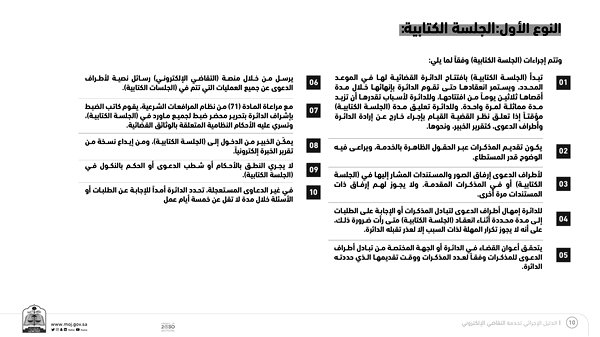

In [ ]:
sample_image_path = "/workspace/pdf_images/0012/page_010.jpg"

display(IPImage(filename=sample_image_path))

In [ ]:
# sample_image_path = "/workspace/pdf_images/0011/page_010.jpg"
sample_image_path = "/workspace/pdf_images/0012/page_010.jpg"

messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": "You are a helpful assistant."}]
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": sample_image_path},
            {"type": "text", "text": task_1_message}
        ]
    }
]


inputs = processor.apply_chat_template(
    messages,

    add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors="pt"
).to(model.device)


input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**inputs, max_new_tokens=2048, do_sample=False)
    generation = generation[0][input_len:]

decoded = processor.decode(generation, skip_special_tokens=True)

# print(decoded)

In [ ]:
from pprint import pprint

# # # task 1
pprint(
    parse_json(decoded)['output']['full_text']
)

('النوع الأول: الجلسة الكتابية:\n'
 'وتتم إجراءات (الجلسة الكتابية) وفقاً لما يلي:\n'
 '01 تبدأ (الجلسة الكتابية) بافتتاح الدائرة القضائية لها في الموعد المحدد، '
 'ويستمر انعقادها حتى تقوم الدائرة بإنهائها خلال مدة أقصاها ثلاثون يوماً من '
 'افتتاحها، وللدائرة لأسباب تقدرها أن تزيد مدة مماثلة لمرة واحدة، وللدائرة '
 'تعليق مدة (الجلسة الكتابية) مؤقتاً إذا تعلق نظر القضية القيام بإجراء خارج عن '
 'إرادة الدائرة وأطراف الدعوى، كتقرير الخبير، ونحوها.\n'
 '02 يكون تقديم المذكرات عبر الحقول الظاهرة بالخدمة، ويراعى فيه الوضوح قدر '
 'المستطاع.\n'
 '03 لأطراف الدعوى إرفاق الصور والمستندات المشار إليها في (الجلسة الكتابية) أو '
 'في المذكرات المقدمة، ولا يجوز لهم إرفاق ذات المستندات مرة أخرى.\n'
 '04 للدائرة إمهال أطراف الدعوى لتبادل المذكرات أو الإجابة على الطلبات إلى مدة '
 'محددة أثناء (الجلسة الكتابية) متى رأت ضرورة ذلك، على أنه لا يجوز تكرار '
 'المهلة لذات السبب إلا لعذر تقبله الدائرة.\n'
 '05 يتحقق أعوان القضاء في الدائرة أو الجهة المختصة من تبادل أطراف الدعوى '
 'للمذكرات وفقاً لعدد ا

In [ ]:
# # # task 2
parse_json(decoded)

## Merge Model

Visit: https://llamafactory.readthedocs.io/en/latest/getting_started/merge_lora.html

Use below configurations.

```yaml
### Note: DO NOT use quantized model or quantization_bit when merging lora adapters

### model
model_name_or_path: google/gemma-3-4b-it
adapter_name_or_path: /workspace/ocr-models-gemma-3-4b-it/checkpoint-1640/
template: gemma3
trust_remote_code: true

### export
export_dir: /workspace/saves/arabic-legal-documents-ocr-1.0-fp32
export_size: 5
export_device: cpu  # choices: [cpu, auto]
export_legacy_format: false

```

## Check Merged Model

In [ ]:
from transformers import AutoProcessor, Gemma3ForConditionalGeneration
from PIL import Image
import torch
from IPython.display import Image as IPImage, display

import json_repair

def parse_json(text):
    try:
        return json_repair.loads(text)
    except:
        return None


In [ ]:
model_id = "/workspace/saves/arabic-legal-documents-ocr-1.0"

# default: Load the model on the available device(s)
model = Gemma3ForConditionalGeneration.from_pretrained(
    model_id,
    dtype="auto", device_map="auto",
)

processor = AutoProcessor.from_pretrained(model_id)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using `use_fast=True` but `torchvision` is not available. Falling back to the slow image processor.


In [ ]:
sample_image_path = "/workspace/pdf_images/0012/page_010.jpg"

messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": "You are a helpful assistant."}]
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": sample_image_path},
            {"type": "text", "text": task_1_message}
        ]
    }
]


inputs = processor.apply_chat_template(
    messages,

    add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors="pt"
).to(model.device)


input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**inputs, max_new_tokens=2048, do_sample=False)
    generation = generation[0][input_len:]

decoded = processor.decode(generation, skip_special_tokens=True)

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [ ]:
from pprint import pprint

# # # task 1
pprint(
    parse_json(decoded)['output']['full_text']
)

('النوع الأول: الجلسة الكتابية:\n'
 'وتتم إجراءات (الجلسة الكتابية) وفقاً لما يلي:\n'
 '01 تبدأ (الجلسة الكتابية) بافتتاح الدائرة القضائية لها في الموعد المحدد، '
 'ويستمر انعقادها حتى تقوم الدائرة بإنهائها خلال مدة أقصاها ثلاثون يوماً من '
 'افتتاحها، وللدائرة لأسباب تقدرها أن تزيد مدة مماثلة لمرة واحدة، وللدائرة '
 'تعليق مدة (الجلسة الكتابية) مؤقتاً إذا تعلق نظر القضية القيام بإجراء خارج عن '
 'إرادة الدائرة وأطراف الدعوى، كتقرير الخبير، ونحوها.\n'
 '02 يكون تقديم المذكرات عبر الحقول الظاهرة بالخدمة، ويراعى فيه الوضوح قدر '
 'المستطاع.\n'
 '03 لأطراف الدعوى إرفاق الصور والمستندات المشار إليها في (الجلسة الكتابية) أو '
 'في المذكرات المقدمة، ولا يجوز لهم إرفاق ذات المستندات مرة أخرى.\n'
 '04 للدائرة إمهال أطراف الدعوى لتبادل المذكرات أو الإجابة على الطلبات إلى مدة '
 'محددة أثناء (الجلسة الكتابية) متى رأت ضرورة ذلك، على أنه لا يجوز تكرار '
 'المهلة لذات السبب إلا لعذر تقبله الدائرة.\n'
 '05 يتحقق أعوان القضاء في الدائرة أو الجهة المختصة من تبادل أطراف الدعوى '
 'للمذكرات وفقاً لعدد ا

## Upload Merged to HuggingFace

In [ ]:
from huggingface_hub import HfApi

api = HfApi()

# Upload the entire directory
api.upload_folder(
    folder_path="/workspace/saves/arabic-legal-documents-ocr-1.0",
    repo_id="bakrianoo/my-ocr-model-1.0",  # Replace with your repo
    repo_type="model",  # or "dataset" or "space"
    # path_in_repo="/custom/folder/"
)

## Run using VLLM

In [ ]:
!pip install -q transformers==4.57.6
!pip install -q optimum==1.26.0
!pip install -q datasets==4.4.0

!pip install -q torch==2.8.0
!pip install -q torchvision==0.23
!pip install -q torchaudio==2.8.0

!pip install -q vllm==0.15.0

In [ ]:
# # ====> Run in separate terminal or via a service

!vllm serve "/workspace/saves/arabic-legal-documents-ocr-1.0" \
--dtype bfloat16 --gpu_memory_utilization 0.8 \
--enable-chunked-prefill \
--allowed-local-media-path "/workspace/"

## VLLM Inference

In [ ]:
!pip install openai json-repair

In [ ]:
import os
import base64
from io import BytesIO
from PIL import Image, ImageEnhance
from tqdm.auto import tqdm
import json_repair
from IPython.display import Image as IPImage, display

task_1_message = """
You are a professional OCR Details Extractor.
Your rule to extract: the page markdown content in addition to the structural_elements of the document.
Extract the final output into a json format.
Do not generate any introduction or conclusion.
""".strip()

task_2_message = """
You are a professional OCR Details Extractor.
Your rule to extract the: document_classification, source, physical_properties, official_marks, signatures_authorization, routing_distribution, attachments_references, condition_notes and confidence_quality of the document.
Extract the final output into a json format.
Do not generate any introduction or conclusion.
""".strip()


def parse_json(text):
    try:
        return json_repair.loads(text)
    except:
        return None



def preprocess_image(image_path, max_width=600, do_enhance: bool=False):
    """
    Preprocess image to reduce size and prepare for OCR.

    Args:
        image_path: String path to the image file
        max_width: Maximum width in pixels (height auto-calculated to maintain ratio)

    Returns:
        base64 encoded string of the preprocessed image

    Steps:
    1. Load image from path
    2. Convert to grayscale (reduces size and improves OCR)
    3. Resize to reasonable width while maintaining aspect ratio
    4. Increase contrast
    5. Convert to base64 string
    """
    # Load image from path
    image = Image.open(image_path)

    # Convert to grayscale
    gray_image = image.convert('L')

    # # Resize if image is too large
    if gray_image.width > max_width:
        # Calculate new height to maintain aspect ratio
        ratio = max_width / gray_image.width
        new_height = int(gray_image.height * ratio)
        gray_image = gray_image.resize((max_width, new_height), Image.LANCZOS)

    if do_enhance:
        # Increase contrast for better OCR
        enhancer = ImageEnhance.Contrast(gray_image)
        gray_image = enhancer.enhance(1.5)  # 1.5x contrast

    # Convert to base64
    buffered = BytesIO()
    gray_image.save(buffered, format="JPEG", optimize=True, quality=99)
    img_base64 = base64.b64encode(buffered.getvalue()).decode('utf-8')

    return f"data:image/jpeg;base64,{img_base64}"

In [ ]:
from openai import OpenAI

client = OpenAI(
    api_key="any",
    base_url="http://localhost:8000/v1"
)

In [ ]:
sample_image_path = "/workspace/pdf_images/0012/page_011.jpg"
b64_image = preprocess_image(sample_image_path)

messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": "You are a helpful assistant."}]
    },
    {
        "role": "user",
        "content": [
            {"type": "image_url", "image_url": {"url": b64_image } },
            {"type": "text", "text": task_1_message}
        ]
    }
]


In [ ]:
import time

start_time = time.perf_counter()

response = client.chat.completions.create(
    model="/workspace/saves/arabic-legal-documents-ocr-1.0",
    messages=messages,
    temperature=0.1
)

end_time = time.perf_counter()
print(f"Execution time: {end_time - start_time:.4f} seconds")

Execution time: 13.3344 seconds


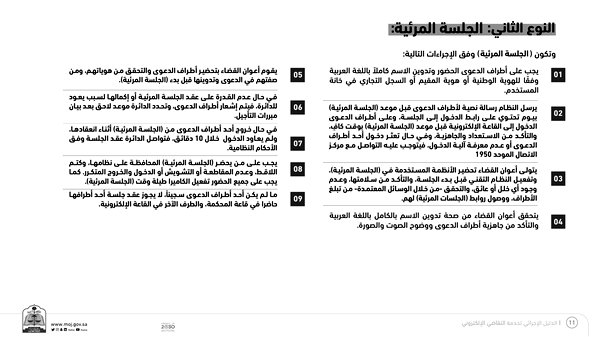

In [ ]:
display(IPImage(filename=sample_image_path))

In [ ]:
parse_json(
    response.choices[0].message.content
)

{'output': {'subject': 'النوع الثاني: الجلسة المرئية',
  'subject_translation': None,
  'keywords': ['الجلسة المرئية',
   'أعوان القضاء',
   'أطراف الدعوى',
   'القاعة الإلكترونية',
   'الإجراءات'],
  'full_text': 'النوع الثاني: الجلسة المرئية:\nوتكون (الجلسة المرئية) وفق الإجراءات التالية:\n01 يجب على أطراف الدعوى الحضور وتدوين الاسم كاملاً باللغة العربية وفقاً للهوية الوطنية أو هوية المقيم أو السجل التجاري في خانة المستخدم.\n02 يرسل النظام رسالة نصية لأطراف الدعوى قبل موعد (الجلسة المرئية) بيوم تحتوي على رابط الدخول إلى الجلسة، وعلى أطراف الدعوى الدخول إلى القاعة الإلكترونية قبل موعد (الجلسة المرئية) بوقت كاف، والتأكد من الاستعداد والجاهزية، وفي حال تعذر دخول أحد أطراف الدعوى أو عدم معرفة آلية الدخول، فيتوجب عليه التواصل مع مركز الاتصال الموحد 1950\n03 يتولى أعوان القضاء تحضير الأنظمة المستخدمة في (الجلسة المرئية)، وتفعيل النظام التقني قبل بدء الجلسة، والتأكد من سلامتها، وعدم وجود أي خلل أو عائق، والتحقق -من خلال الوسائل المعتمدة- من تبلغ الأطراف، ووصول روابط (الجلسات المرئية) لهم.\n